In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import mysql.connector
import warnings
warnings.filterwarnings('ignore')


In [2]:
#importing the data
df = pd.read_csv("C:\\Users\\91886\\Desktop\\My Computer\\Project_guvi\\Healthcare_project\\Healtcare-Dataset.xlsx - Sheet1.csv")
df.head()

,Patient_ID,Admit_Date,Discharge_Date,Diagnosis,Bed_Occupancy,Test,Doctor,Followup Date,Feedback,Billing Amount,Health Insurance Amount
0,23571,12/31/2022,1/12/2023,Viral Infection,General,MRI,Jay Sinha,1/20/2023,5.0,13234,11911
1,27781,1/4/2023,1/12/2023,Typhoid,ICU,MRI,Jaya Yaadav,1/16/2023,4.0,12241,11017
2,24413,1/5/2023,1/12/2023,Malaria,General,CT Scan,Jay Sinha,1/15/2023,5.0,35255,31730
3,27360,1/5/2023,1/12/2023,Flu,Private,X-Ray,Jaya Yaadav,1/19/2023,5.0,6582,5924
4,26097,1/6/2023,1/12/2023,Viral Infection,General,Blood Test,Jaya Yaadav,2/6/2023,4.9,4567,4110


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7157 entries, 0 to 7156
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               7157 non-null   int64  
 1   Admit_Date               7157 non-null   object 
 2   Discharge_Date           7157 non-null   object 
 3   Diagnosis                7157 non-null   object 
 4   Bed_Occupancy            7157 non-null   object 
 5   Test                     7157 non-null   object 
 6   Doctor                   7157 non-null   object 
 7   Followup Date            7035 non-null   object 
 8   Feedback                 7157 non-null   float64
 9   Billing Amount           7157 non-null   int64  
 10  Health Insurance Amount  7157 non-null   int64  
dtypes: float64(1), int64(3), object(7)
memory usage: 615.2+ KB


In [4]:
df['Admit_Date']= pd.to_datetime(df['Admit_Date'])
df['Discharge_Date']= pd.to_datetime(df['Discharge_Date'])
df['Followup Date']= pd.to_datetime(df['Followup Date'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7157 entries, 0 to 7156
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Patient_ID               7157 non-null   int64         
 1   Admit_Date               7157 non-null   datetime64[ns]
 2   Discharge_Date           7157 non-null   datetime64[ns]
 3   Diagnosis                7157 non-null   object        
 4   Bed_Occupancy            7157 non-null   object        
 5   Test                     7157 non-null   object        
 6   Doctor                   7157 non-null   object        
 7   Followup Date            7035 non-null   datetime64[ns]
 8   Feedback                 7157 non-null   float64       
 9   Billing Amount           7157 non-null   int64         
 10  Health Insurance Amount  7157 non-null   int64         
dtypes: datetime64[ns](3), float64(1), int64(3), object(4)
memory usage: 615.2+ KB


In [6]:
df.isnull().sum()

Patient_ID                   0
Admit_Date                   0
Discharge_Date               0
Diagnosis                    0
Bed_Occupancy                0
Test                         0
Doctor                       0
Followup Date              122
Feedback                     0
Billing Amount               0
Health Insurance Amount      0
dtype: int64

In [7]:
df.replace(to_replace=np.nan, value= 0000-00-00)

,Patient_ID,Admit_Date,Discharge_Date,Diagnosis,Bed_Occupancy,Test,Doctor,Followup Date,Feedback,Billing Amount,Health Insurance Amount
0,23571,2022-12-31,2023-01-12,Viral Infection,General,MRI,Jay Sinha,2023-01-20 00:00:00,5.0,13234,11911
1,27781,2023-01-04,2023-01-12,Typhoid,ICU,MRI,Jaya Yaadav,2023-01-16 00:00:00,4.0,12241,11017
2,24413,2023-01-05,2023-01-12,Malaria,General,CT Scan,Jay Sinha,2023-01-15 00:00:00,5.0,35255,31730
3,27360,2023-01-05,2023-01-12,Flu,Private,X-Ray,Jaya Yaadav,2023-01-19 00:00:00,5.0,6582,5924
4,26097,2023-01-06,2023-01-12,Viral Infection,General,Blood Test,Jaya Yaadav,2023-02-06 00:00:00,4.9,4567,4110
...,...,...,...,...,...,...,...,...,...,...,...
7152,29885,2024-03-03,2024-03-07,Typhoid,Private,Blood Test,Jay Sinha,2024-03-10 00:00:00,5.0,2342,2108
7153,26517,2024-03-04,2024-03-07,Pneumonia,Private,CT Scan,Jaya Yaadav,2024-03-14 00:00:00,5.0,24943,22449
7154,28201,2024-03-05,2024-03-07,Flu,General,Blood Test,Jay Sinha,0,3.5,2343,2109
7155,24833,2024-03-06,2024-03-07,Typhoid,Private,X-Ray,Mark Joy,2024-03-15 00:00:00,4.9,3475,3128


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7157 entries, 0 to 7156
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Patient_ID               7157 non-null   int64         
 1   Admit_Date               7157 non-null   datetime64[ns]
 2   Discharge_Date           7157 non-null   datetime64[ns]
 3   Diagnosis                7157 non-null   object        
 4   Bed_Occupancy            7157 non-null   object        
 5   Test                     7157 non-null   object        
 6   Doctor                   7157 non-null   object        
 7   Followup Date            7035 non-null   datetime64[ns]
 8   Feedback                 7157 non-null   float64       
 9   Billing Amount           7157 non-null   int64         
 10  Health Insurance Amount  7157 non-null   int64         
dtypes: datetime64[ns](3), float64(1), int64(3), object(4)
memory usage: 615.2+ KB


In [9]:
 df

,Patient_ID,Admit_Date,Discharge_Date,Diagnosis,Bed_Occupancy,Test,Doctor,Followup Date,Feedback,Billing Amount,Health Insurance Amount
0,23571,2022-12-31,2023-01-12,Viral Infection,General,MRI,Jay Sinha,2023-01-20,5.0,13234,11911
1,27781,2023-01-04,2023-01-12,Typhoid,ICU,MRI,Jaya Yaadav,2023-01-16,4.0,12241,11017
2,24413,2023-01-05,2023-01-12,Malaria,General,CT Scan,Jay Sinha,2023-01-15,5.0,35255,31730
3,27360,2023-01-05,2023-01-12,Flu,Private,X-Ray,Jaya Yaadav,2023-01-19,5.0,6582,5924
4,26097,2023-01-06,2023-01-12,Viral Infection,General,Blood Test,Jaya Yaadav,2023-02-06,4.9,4567,4110
...,...,...,...,...,...,...,...,...,...,...,...
7152,29885,2024-03-03,2024-03-07,Typhoid,Private,Blood Test,Jay Sinha,2024-03-10,5.0,2342,2108
7153,26517,2024-03-04,2024-03-07,Pneumonia,Private,CT Scan,Jaya Yaadav,2024-03-14,5.0,24943,22449
7154,28201,2024-03-05,2024-03-07,Flu,General,Blood Test,Jay Sinha,NaT,3.5,2343,2109
7155,24833,2024-03-06,2024-03-07,Typhoid,Private,X-Ray,Mark Joy,2024-03-15,4.9,3475,3128


In [10]:
healthcare_data = df

In [12]:
import mysql.connector

mydb = mysql.connector.connect(host = "localhost",
                               user = "root",
                               password = "root",
                               database = "healthcare_db"
                               )
cursor= mydb.cursor()

create_query_1= '''CREATE TABLE IF NOT EXISTS healthcare_data(Patient_ID int,
                                                              Admit_Date date,
                                                              Discharge_Date date,
                                                              Diagnosis varchar(255),
                                                              Bed_Occupancy varchar(255),
                                                              Test varchar(255),
                                                              Doctor varchar(255),
                                                              Followup_Date date,
                                                              Feedback float,
                                                              Billing_Amount int,
                                                              Health_Insurance_Amount int
                                                              )'''

cursor.execute(create_query_1)
mydb.commit()

insert_query_1 = ''' INSERT INTO healthcare_data(Patient_ID, Admit_Date, Discharge_Date,
                                                 Diagnosis, Bed_Occupancy, Test, Doctor, Followup_Date,
                                                 Feedback, Billing_Amount, Health_Insurance_Amount)
                                                 
                                                 values(%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)'''

data = healthcare_data.values.tolist()
cursor.executemany(insert_query_1, data)
mydb.commit()


In [12]:
Diagnosis = df.groupby("Diagnosis")["Patient_ID"].count()
Diagnosis


Diagnosis
Flu                 1717
Fracture             287
Malaria             1431
Pneumonia            573
Typhoid             1145
Viral Infection     2004
Name: Patient_ID, dtype: int64

In [13]:
Doctor = df.groupby("Doctor")["Patient_ID"].count()
Doctor

Doctor
Jay Sinha         1023
Jaya Yaadav       1023
Mark Joy          1023
Naresh Goyenka    1022
Niki Sharma       1022
Ravi D            1022
Tejas Saxena      1022
Name: Patient_ID, dtype: int64

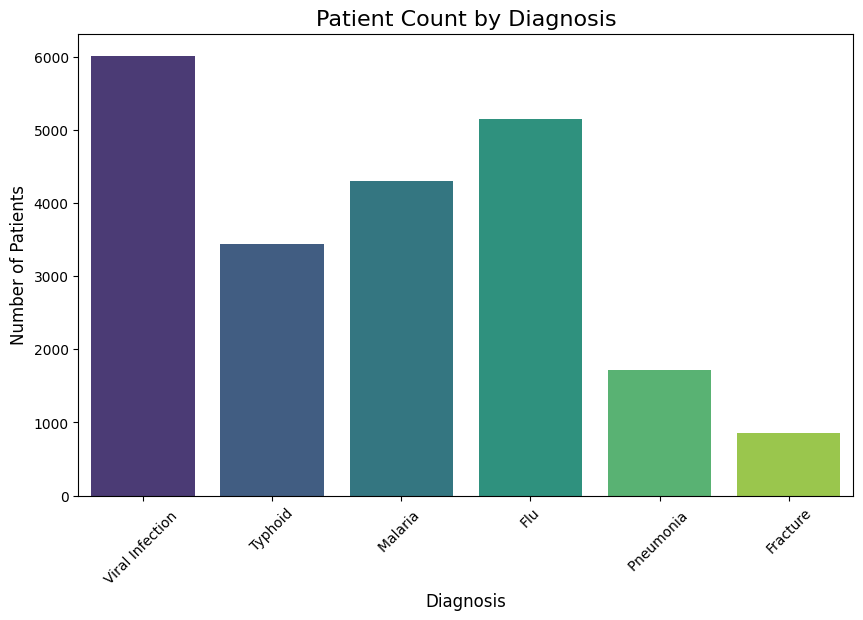

In [18]:
import mysql.connector
mydb = mysql.connector.connect(host = "localhost",
                               user = "root",
                               password = "root",
                               database = "healthcare_db"
                               )
cursor= mydb.cursor()

query1= f'''SELECT Diagnosis,
            COUNT(Patient_ID) AS patient_count
            FROM healthcare_data
            GROUP BY Diagnosis;'''

cursor.execute(query1)
table_1= cursor.fetchall()
mydb.commit()

df_1= pd.DataFrame(table_1, columns= ("Diagnosis", "Patient_count"))

#fig_amount_1= px.bar(df_1,x="Diagnosis", y="Patient_count", title= "DIAGNOSIS NY TOTAL PATIENT", hover_name= "Diagnosis",
                       # color_discrete_sequence=px.colors.sequential.Magenta_r, height= 650, width= 600)
#fig_amount_1.show()

plt.figure(figsize=(10,6))
sns.barplot(x="Diagnosis", y="Patient_count", data=df_1, palette="viridis")

plt.title("Patient Count by Diagnosis", fontsize=16)
plt.xlabel("Diagnosis", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


KeyError: 'Age'

<Figure size 800x500 with 0 Axes>

In [15]:
plt.figure(figsize=(6,6))
df['Gender'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, shadow=True)
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

KeyError: 'Gender'

<Figure size 600x600 with 0 Axes>